# Class 19: Monte Carlo Integration

Ch. 10, section 2: Monte Carlo Integration methods 
- "hit-or-miss" method
- mean value method
- multiple dimensions
- gaussian nonuniform & importance sampling

Complete the activities as instructed by the professor

#### Import any packages we need below (update as we go):

In [1]:
import random 
import numpy as np
import matplotlib.pyplot as plt

### Monte Carlo Integration - "hit-or-miss" method 

Solve example problem of
$$I = \int_0^2 \sin^2 \left[ \frac{1}{x(2-x)} \right]dx$$

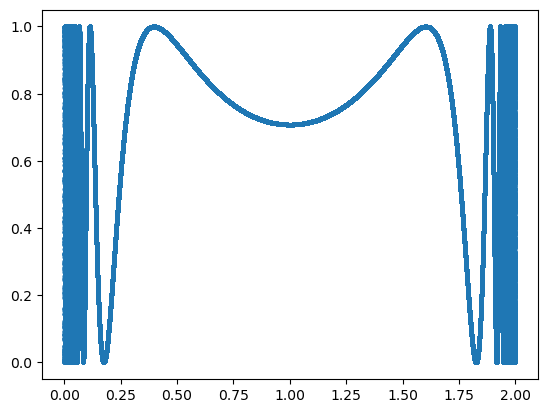

1.451624


In [10]:
def f(x):
    return (np.sin(1/(x*(2-x))))**2

#plot to visualize
N = 1000000
x0 = 0
xf = 2
h = (xf-x0)/N
x_arr = np.arange(x0+h,xf,h)
y_arr = f(x_arr)

plt.scatter(x_arr, y_arr, s=4)
plt.show()

area = 2.0 #width*height of plot box
k = 0 #counts hits

#Monte Carlo
for i in range(N):
    x = 2*random.random()
    y = random.random()
    if y < f(x):
        k += 1

#calculate integral
result = k*area/N
print(result)

### Mean Value Method

Mutiple dimensions - area of a circle (2D)

Let's apply this method to evaluate the area of a unit circle (radius = 1). 

The area of the unit circle is given by
$$ I = \iint_{-1}^{+1} f(x,y) dx dy $$
where $f(x,y) = 1$ everywhere inside the circle and zero everywhere outside. In other words:
$$ f(x,y) =  \begin{cases}
                     1  & \qquad\text{if $x^2 +y^2 \leq 1$,} \\
                     0 & \qquad\text{otherwise}
                   \end{cases}$$
     

The 2D version of the mean value method for this problem would be:
$$I \simeq \frac{4}{N} \sum_{i=1}^N f(x_i, y_i) $$

In [18]:
def f(x,y,z):
    if x**2+y**2+z**2 <= 1:
        return 1
    else:
        return 0

L = 2
N = 1000000
tot = 0

for i in range(N):
    x = 2*random.random() -1
    y = 2*random.random() -1
    z = 2*random.random() -1
    tot += f(x,y,z)

result = tot*L**3/N
print(result)
print(4*np.pi/3)

4.185632
4.1887902047863905


### Importance Sampling

**Exercise 10.9:** Consider the integral
$$ I = \int_0^1 \frac{x^{-1/2}}{e^x+1} dx,$$
which arises in the theory of Fermi gases. This integral would be problematic for any of our standard integration methods, such as the trapezoidal rule, or for the Monte Carlo integration with the standard mean value method, becuase the integrand varies widely and in fact diverges at $x = 0$. We can, however, evaluate it straightforwardly using importance sampling. 

**(a)** Show that 
$$w(x) = \frac{1}{2\sqrt{x}}$$
if a properly normalized probability distribution in the interval $[0,1]$ and derive the tranformation formula for generating random numbers between zero and one from this distribution. 

**(b)** Calculate a value for the integral above using the importance sampling formula of Eq. (10.37) and this choice of $w(x)$ with one million sample points. You should get a value around 0.84. 

##### Solution

**(a)**

Importance sampling equation, Eq (10.37):  
$$ \int_a^b f(x) dx  \simeq \frac{1}{N} \sum_{i=1}^N \frac{f(x_i)}{w(x_i)} $$

A properly normalized probability distribution should have: $\int_a^b w(x) dx = 1$, so
$$\int_0^1 x^{-1/2} dx = 2 \sqrt{x } \hspace{1mm} \Big|_0^1 = 2 $$

Hence $w(x) = p(x) = \frac{1}{2}x^{-1/2}$. 


Applying Eq. (10.7) for the tranformation method, $ \int_{-\infty}^{x} p(x') dx' = \int_0^z dz' = z $, we have
$$z = \frac{1}{2} \int_0^x x^{-1/2} dx = \sqrt{x}$$

and hence $x = z^2$. Then Eq. (10.37) tells us that 

$$\int_0^1 \frac{x^{-1/2}}{e^x +1} dx \simeq \frac{1}{N} \sum_{i=1}^N \frac{x_i^{-1/2}}{\exp(x_i^2)+1} \frac{2}{x_i^{-1/2}} \simeq \frac{2}{N} \sum_{i=1}^N \frac{1}{\exp(z_i^2)+1},$$

where $z_i$ is a uniformly distributed random number between $0$ and $1$. 

In [19]:
def h(z):
    return 1/(np.exp(z**2)+1)

N = 100000
s = 0

for i in range(N):
    z = random.random()
    s += h(z)

I = (2/N)*s
print(I)

0.8390693469211733


#### Example 10.2: Rutherford Scattering 

At the beginning of the 20th centurey, Ernest Rutherford and his collaborators showed that when an $alpha$ partiles, i.e. a helium nucleius of two protons and two neutrons, passes close to an atom as shown in the figure, it is scattered, primarily by electrical repulsion from the positively charged nucleus of the atoms, and that the angle $\theta$ through which it is scattered obeys
$$ \tan \frac{1}{2}\theta = \frac{Ze^2}{2\pi \epsilon_0 Eb} $$

where $Z$ is the atomic number of the nucelus, $e$ is the electron charge, $\epsilon_0$ is the permittivity of free space, $E$ is the kinetic energy of the incident $\alpha$ particle, and $b$ is the impact parameter, i.e., the perpendicular distance between the particle's initial trajectory and the axis running through the nucelus. 

Consdier a beam of particles with energy 7.7 MeV that has a Gaussian profile in both is $x$ and $y$ axes with standard deviation $\sigma = a_0/100$, where $a_0$ is the Bohr radius. The beam is fired directly at a gold atom. Let us simulate the scattering process for one million $\alpha$ particles and calculate the fraction of particles that "bounce back" on scattering, i.e., that scatter through angles greater than $90\degree$. The threshold value of the impact parameter for which this happens can be calculated from Eq. 10.19 with $\theta = 90\degree$, which gives
$$b = \frac{Ze^2}{2\pi\epsilon_0E}$$
If $b$ is less than this value then the particle bounces back. 

In [21]:
# Constants
Z = 79
e = 1.602e-19
E = 7.7e6*e
epsilon0 = 8.854e-12
a0 = 5.292e-11
sigma = a0/100
N = 1000000

# Function to generate two Gaussian random numbers
def gaussian():
    r = np.sqrt(-2*sigma**2*np.log(1-random.random()))
    theta = 2*np.pi*random.random()
    x = r*np.cos(theta)
    y = r*np.sin(theta)
    return x,y

# Main program
count = 0
for i in range(N):
    x,y = gaussian()
    b = np.sqrt(x**2+y**2)
    if b<Z*e*e/(2*np.pi*epsilon0*E):
        count += 1

print(count, "particles were reflected out of",N, "(", count/N*100,"%)")

1542 particles were reflected out of 1000000 ( 0.1542 %)
